# 01 Generative Ai Ethics

## 📚 Learning Objectives

By completing this notebook, you will:
- Identify ethical risks of generative AI (deepfakes, bias)
- Apply guidelines and mitigation strategies

## 🔗 Where this fits

**Builds on:** Course 06 (AIAT 116) — Units 1-2 (ethical frameworks, bias and fairness) and Course 10 — Unit 3, lesson 05: you now know what these systems can produce, which is what makes the risk concrete.

**Used later in:** Course 10 — Unit 4, lessons 02-04, which each take one risk and make it measurable.

---

## 🌍 Why this lesson exists — Google pauses Gemini, 22 February 2024

On 22 February 2024 Google **suspended Gemini's ability to generate images of people**. The model had been tuned to increase demographic diversity in its outputs, and the tuning did not know when to stop: prompts for "a 1943 German soldier" returned racially diverse soldiers in Nazi uniforms, and the US Founding Fathers came back as people of colour. Google apologised publicly and paused the feature.

Read that next to the failure it was trying to fix. Bianchi et al. (FAccT 2023, arXiv 2211.03759) had shown that ordinary prompts to text-to-image systems *amplify* demographic stereotypes at scale. Google's intervention was aimed at a real, documented problem — and shipped without a measurement that would have caught the over-correction.

**What goes wrong without this:** "we removed the protected attribute" and "we tuned for diversity" are both interventions engineers *believe* work. Neither is a measurement. Without slicing outputs by group and comparing, you cannot tell a fix from a new failure — you find out when it is on the front page.


## Why Ethics Matters for Generative AI

Generative models do not just *analyze* data — they **produce new content** (text, images, audio, code) that can influence people directly. That creates ethical questions that classic ML did not face at the same scale:

- **Bias & fairness** — models reproduce and can amplify patterns in their training data
- **Misinformation & deepfakes** — synthetic media can impersonate real people convincingly
- **Copyright & intellectual property** — models are trained on (and can imitate) creative work
- **Privacy & data protection** — models can memorize and leak personal data from training sets

The sections below walk through each risk, then we get hands-on and *measure* bias in a small model.

### Bias and Fairness

A generative model learns the statistics of its training data — **including its stereotypes**. Documented examples:

- Text-to-image models skew by occupation — prompt "a CEO" and you mostly get men, "a nurse" and you mostly get women. Luccioni et al., *Stable Bias* (2023), measured this across DALL·E 2, Stable Diffusion v1.4 and v2: the outputs correlate with US labour demographics but "consistently under-represent marginalized identities to different extents"
- Language models complete "The doctor said..." with *he* and "The nurse said..." with *she* far more often than real-world demographics justify — notebook `03` in this unit measures exactly this on a model you train yourself
- Amazon scrapped an experimental hiring model in 2018 after it learned to penalize resumes that mentioned "women's" activities (Reuters, Jeffrey Dastin, 2018)

**Key idea:** bias is not a bug added by the model — it is a property of the data the model faithfully learned. That is why detection (measuring outputs) and mitigation (fixing data/training/outputs) are separate engineering steps — notebook `03` in this unit is dedicated to them.

### Deepfakes and Misinformation

**Deepfakes** are synthetic images, video, or audio depicting real people saying or doing things they never did. Risks include fraud (cloned voices used in scam calls), political misinformation, and non-consensual imagery.

Defenses come in layers:

1. **Detection** — classifiers trained to spot generation artifacts (notebook `02` in this unit builds one)
2. **Provenance** — watermarking and content credentials (e.g., the C2PA standard) that mark content as AI-generated at creation time
3. **Regulation** — the EU AI Act (Regulation (EU) 2024/1689), **Article 50**, requires providers to mark synthetic audio/image/video/text "in a machine-readable format and detectable as artificially generated or manipulated", and requires deployers of deepfakes to disclose them

### Copyright and Intellectual Property

Generative models are trained on large scraped corpora that include copyrighted books, articles, images, and code. Two open legal questions:

- **Training**: is training on copyrighted work "fair use"? Ongoing lawsuits (e.g., Getty Images v. Stability AI, The New York Times v. OpenAI) are testing this
- **Output**: who owns generated content, and what happens when a model reproduces a protected work or a living artist's style nearly verbatim?

Practical guidance for engineers: know your training-data licenses, honor opt-outs, and treat verbatim regurgitation of training data as a defect to test for.

### Privacy and Data Protection

Generative models can **memorize** rare training examples — researchers have extracted names, phone numbers, and addresses from language models. Under the EU's **GDPR** this matters directly: personal data in a training set is still personal data, with rules on consent, purpose, minimization, and the right to erasure.

We only preview the idea here — notebook `04` in this unit applies GDPR principles (consent, data minimization, right to erasure, right to explanation) to a concrete ML pipeline, step by step.

### Responsible-AI Frameworks

You do not have to invent ethics from scratch — several frameworks already define what "responsible" means in practice:

| Framework | What it is | What it asks of you |
|---|---|---|
| **EU AI Act** (2024) | First binding AI law; risk-based tiers | High-risk systems need bias testing, documentation, human oversight |
| **NIST AI RMF** (2023) | Voluntary US risk-management framework | Map, measure, and manage AI risks across the lifecycle |
| **UNESCO Recommendation** (2021) | Global ethics standard adopted by 190+ states | Human rights, transparency, and accountability principles |

Day-to-day engineering practices that implement these: **model cards** (document what a model can and cannot do), **datasheets for datasets** (document where data came from), and **fairness audits** (measure disparities before deployment) — which is exactly what we do next.

---

## From Principles to Practice

Talking about fairness is easy; **measuring** it is the engineering skill. Below we audit a small classifier for demographic bias — the same workflow (train, slice metrics by group, compare) applies to auditing generative models, where you slice *generated outputs* by group instead.

## 🌍 Real-World Worked Example — Detecting Gender Bias in a Classifier

**Industry context — three real, sourced incidents:**
- Amazon scrapped an experimental hiring model in 2018 after it penalised resumes mentioning "women's" activities (Reuters, 2018)
- A widely used US healthcare risk model gave Black patients lower risk scores than equally sick white patients (Obermeyer et al., *Science* 366, 2019)
- With identical targeting settings, Facebook delivered a truck-driver job ad to 4,864 men and 386 women, and a childcare ad to 6,456 women and 258 men (AlgorithmWatch, 2020)

We **measure and visualise** demographic bias in a classifier trained on the real Titanic manifest — the audit step that toolkits such as Fairlearn (Microsoft) and AI Fairness 360 (IBM) were built to support.

Loaded 891 real passenger records
Real missing values — Age: 177, Cabin: 687, Embarked: 2

Real outcome in the historical record:
  women survived: 74.2%   men survived: 18.9%
  disparity in the ground truth itself: 55.3%

model                    accuracy  female +rate  male +rate     gap
aware (uses Sex)            79.9%         90.7%        8.8%   81.9%
blind (Sex dropped)         70.1%         35.1%       21.6%   13.4%

Proxy check: Sex predicted from the 'blind' features alone = 66.0% (majority-class baseline 63.8%)


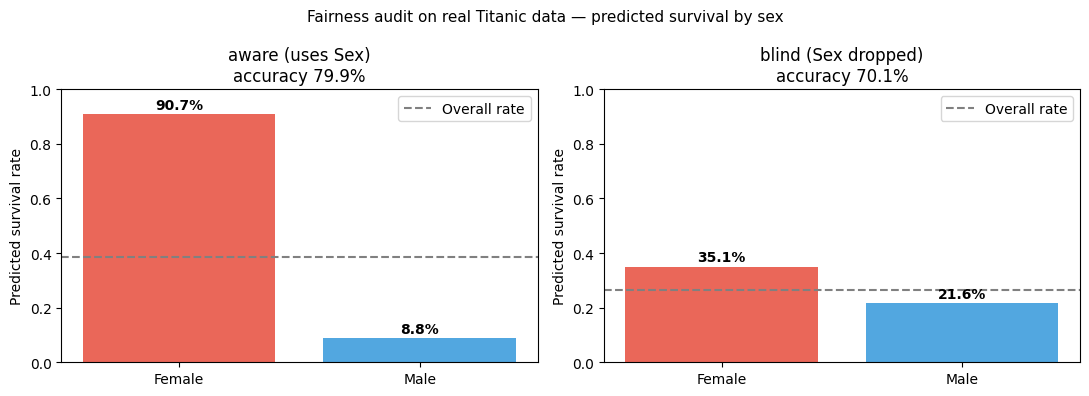


What the audit actually found:
  1. Dropping Sex cut the predicted-rate gap from 81.9% to 13.4% —
     but it did NOT reach zero, and accuracy fell 79.9% → 70.1% (9.7% lost).
  2. Equal opportunity (true-positive rate among passengers who DID survive):
     aware  — women 97.1% vs men 24.2%
     blind  — women 44.3% vs men 48.5%
  3. The real disparity is untouched. 74.2% of women and 18.9% of men actually survived;
     hiding the column changes the model, not the world it learns from.

'Fairness through unawareness' is a weak guarantee: it costs accuracy, it
leaves a residual gap, and where proxy features are strong it does not even
hide the attribute. Real audits use Fairlearn (Microsoft) or IBM AI Fairness
360 and report several metrics, because no single number settles fairness.


In [1]:
# WHAT/WHY: a hands-on fairness audit on REAL data — the Titanic passenger
# manifest, a historical decision process with a documented demographic
# disparity. We train the model WITH and WITHOUT the protected attribute
# (Sex) and measure what "fairness through unawareness" actually buys.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ── REAL DATA: 891 passengers of the RMS Titanic ──────────────────────────
TITANIC = '../../../Course 04/datasets/raw/titanic.csv'
df = pd.read_csv(TITANIC)
print(f'Loaded {len(df)} real passenger records')
print(f'Real missing values — Age: {df["Age"].isna().sum()}, '
      f'Cabin: {df["Cabin"].isna().sum()}, Embarked: {df["Embarked"].isna().sum()}')

d = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
# Real missingness has to be handled before modelling; median imputation is the
# simplest defensible choice and we state it rather than hiding it.
d['Age'] = d['Age'].fillna(d['Age'].median())
d['male'] = (d['Sex'] == 'male').astype(int)

# ── The disparity is IN THE DATA, before any model exists ─────────────────
rate_by_sex = d.groupby('Sex')['Survived'].mean()
print(f"\nReal outcome in the historical record:")
print(f"  women survived: {rate_by_sex['female']:.1%}   men survived: {rate_by_sex['male']:.1%}")
print(f"  disparity in the ground truth itself: "
      f"{abs(rate_by_sex['female'] - rate_by_sex['male']):.1%}")

FEAT_AWARE = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male']   # includes Sex
FEAT_BLIND = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']           # Sex removed
tr, te = train_test_split(d, test_size=0.3, random_state=42, stratify=d['Survived'])
male_te = te['male'].to_numpy() == 1
y_te = te['Survived'].to_numpy()

# ── Train two models: sex-aware and sex-blind ─────────────────────────────
results = {}
print(f"\n{'model':<24}{'accuracy':>9}{'female +rate':>14}{'male +rate':>12}{'gap':>8}")
for name, feats in [('aware (uses Sex)', FEAT_AWARE), ('blind (Sex dropped)', FEAT_BLIND)]:
    m = LogisticRegression(max_iter=2000).fit(tr[feats], tr['Survived'])
    pred = m.predict(te[feats])
    rate_f, rate_m = pred[~male_te].mean(), pred[male_te].mean()
    acc = accuracy_score(y_te, pred)
    results[name] = dict(pred=pred, acc=acc, rate_f=rate_f, rate_m=rate_m,
                         gap=abs(rate_m - rate_f),
                         tpr_f=pred[(~male_te) & (y_te == 1)].mean(),
                         tpr_m=pred[(male_te) & (y_te == 1)].mean())
    print(f"{name:<24}{acc:9.1%}{rate_f:14.1%}{rate_m:12.1%}{abs(rate_m-rate_f):8.1%}")

# ── Does dropping Sex actually hide it? Test for PROXIES ──────────────────
# If the remaining features predict Sex better than always guessing the
# majority, a model can rediscover it - "unawareness" is not erasure.
proxy = LogisticRegression(max_iter=2000).fit(tr[FEAT_BLIND], tr['male'])
proxy_acc = proxy.score(te[FEAT_BLIND], te['male'])
majority = max(te['male'].mean(), 1 - te['male'].mean())
print(f"\nProxy check: Sex predicted from the 'blind' features alone = {proxy_acc:.1%} "
      f"(majority-class baseline {majority:.1%})")

# ── Visualise ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, results):
    r = results[name]
    bars = ax.bar(['Female', 'Male'], [r['rate_f'], r['rate_m']],
                  color=['#e74c3c', '#3498db'], alpha=0.85)
    ax.set_ylim(0, 1)
    ax.set_title(f"{name}\naccuracy {r['acc']:.1%}")
    ax.axhline(r['pred'].mean(), color='gray', linestyle='--', label='Overall rate')
    ax.legend(); ax.set_ylabel('Predicted survival rate')
    for bar, rate in zip(bars, [r['rate_f'], r['rate_m']]):
        ax.text(bar.get_x() + bar.get_width()/2, rate + 0.02, f"{rate:.1%}",
                ha='center', fontweight='bold')
plt.suptitle('Fairness audit on real Titanic data — predicted survival by sex', fontsize=11)
plt.tight_layout(); plt.show()

# ── Read the numbers, not the wish ────────────────────────────────────────
a, b = results['aware (uses Sex)'], results['blind (Sex dropped)']
print(f"\nWhat the audit actually found:")
print(f"  1. Dropping Sex cut the predicted-rate gap from {a['gap']:.1%} to {b['gap']:.1%} —")
print(f"     but it did NOT reach zero, and accuracy fell "
      f"{a['acc']:.1%} → {b['acc']:.1%} ({a['acc']-b['acc']:.1%} lost).")
print(f"  2. Equal opportunity (true-positive rate among passengers who DID survive):")
print(f"     aware  — women {a['tpr_f']:.1%} vs men {a['tpr_m']:.1%}")
print(f"     blind  — women {b['tpr_f']:.1%} vs men {b['tpr_m']:.1%}")
print(f"  3. The real disparity is untouched. {rate_by_sex['female']:.1%} of women and "
      f"{rate_by_sex['male']:.1%} of men actually survived;")
print(f"     hiding the column changes the model, not the world it learns from.")
print("\n'Fairness through unawareness' is a weak guarantee: it costs accuracy, it")
print("leaves a residual gap, and where proxy features are strong it does not even")
print("hide the attribute. Real audits use Fairlearn (Microsoft) or IBM AI Fairness")
print("360 and report several metrics, because no single number settles fairness.")


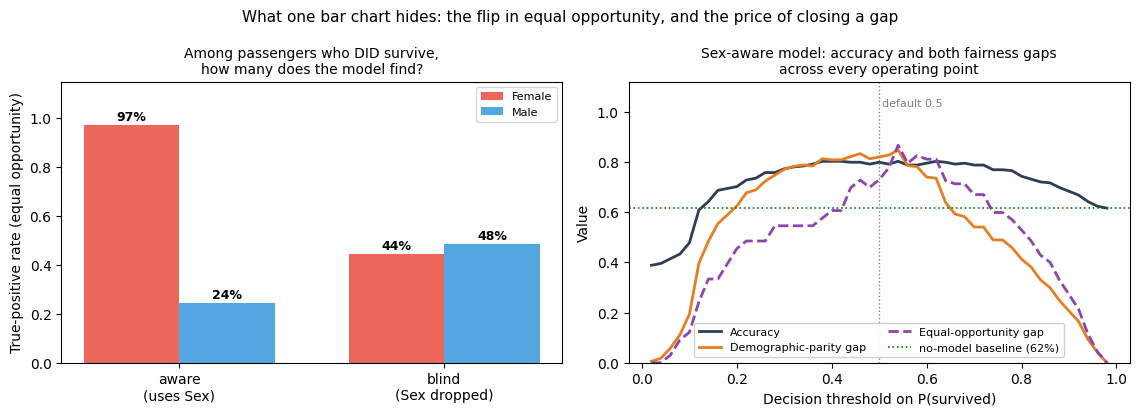

Threshold sweep of the sex-aware model (49 operating points):
  best accuracy 80.2% at threshold 0.38 — parity gap 81.3%, equal-opportunity gap 57.6%
  thresholds where BOTH gaps are under 5 points: 4 of 49; best accuracy among them 62.3% (vs 61.6% for a model that predicts one label for everyone)
  at the default threshold 0.50 — accuracy 79.9%, parity gap 81.9%, equal-opportunity gap 72.9%


In [2]:
# WHAT/WHY: the bar chart above answers ONE question - "is there a gap in who gets a
# positive prediction?" The lesson makes two further claims that no single bar chart can
# show: that unawareness FLIPPED equal opportunity, and that no operating point of this
# model gives you fairness for free. Both are drawn below from the two models already
# trained above - no new data, no new assumptions, same real manifest.
thresholds = np.linspace(0.02, 0.98, 49)


def sweep(feats):
    """Refit one model and, at every decision threshold, record three numbers:
    accuracy, the demographic-parity gap (difference in POSITIVE RATE between sexes)
    and the equal-opportunity gap (difference in TRUE-POSITIVE RATE between sexes)."""
    m = LogisticRegression(max_iter=2000).fit(tr[feats], tr['Survived'])
    p = m.predict_proba(te[feats])[:, 1]          # probability of 'survived'
    survived = y_te == 1                          # who actually survived, for equal opportunity
    acc, dp_gap, eo_gap = [], [], []
    for t in thresholds:
        yhat = (p >= t).astype(int)
        acc.append(float((yhat == y_te).mean()))
        dp_gap.append(abs(yhat[male_te].mean() - yhat[~male_te].mean()))
        eo_gap.append(abs(yhat[male_te & survived].mean()
                          - yhat[(~male_te) & survived].mean()))
    return np.array(acc), np.array(dp_gap), np.array(eo_gap)


acc_a, dp_a, eo_a = sweep(FEAT_AWARE)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4.2))

# ── LEFT: equal opportunity - among people who ACTUALLY survived, who does the model find? ──
names = list(results)
x = np.arange(len(names)); w = 0.36
axL.bar(x - w/2, [results[n]['tpr_f'] for n in names], w, label='Female', color='#e74c3c', alpha=0.85)
axL.bar(x + w/2, [results[n]['tpr_m'] for n in names], w, label='Male', color='#3498db', alpha=0.85)
for i, n in enumerate(names):
    axL.text(i - w/2, results[n]['tpr_f'] + 0.02, f"{results[n]['tpr_f']:.0%}", ha='center', fontsize=9, fontweight='bold')
    axL.text(i + w/2, results[n]['tpr_m'] + 0.02, f"{results[n]['tpr_m']:.0%}", ha='center', fontsize=9, fontweight='bold')
axL.set_xticks(x); axL.set_xticklabels(['aware\n(uses Sex)', 'blind\n(Sex dropped)'])
axL.set_ylim(0, 1.15); axL.set_ylabel('True-positive rate (equal opportunity)')
axL.set_title('Among passengers who DID survive,\nhow many does the model find?', fontsize=10)
axL.legend(fontsize=8)

# ── RIGHT: sweep the decision threshold - can any operating point be accurate AND equal? ──
axR.plot(thresholds, acc_a, color='#2c3e50', lw=2, label='Accuracy')
axR.plot(thresholds, dp_a, color='#e67e22', lw=2, label='Demographic-parity gap')
axR.plot(thresholds, eo_a, color='#8e44ad', lw=2, ls='--', label='Equal-opportunity gap')
axR.axvline(0.5, color='gray', ls=':', lw=1)
axR.text(0.505, 1.02, 'default 0.5', fontsize=8, color='gray')
# The reference line: accuracy you get for free by predicting one label for everyone.
base_rate = max(y_te.mean(), 1 - y_te.mean())
axR.axhline(base_rate, color='green', ls=':', lw=1.2,
            label=f'no-model baseline ({base_rate:.0%})')
axR.set_xlabel('Decision threshold on P(survived)'); axR.set_ylabel('Value')
axR.set_ylim(0, 1.12)
axR.set_title('Sex-aware model: accuracy and both fairness gaps\nacross every operating point', fontsize=10)
axR.legend(fontsize=8, loc='lower center', ncol=2, framealpha=0.9)
plt.suptitle('What one bar chart hides: the flip in equal opportunity, and the price of closing a gap',
             fontsize=11)
plt.tight_layout(); plt.show()

# ── State, from the run, exactly what the right-hand panel shows ───────────
best_acc_i = int(np.argmax(acc_a))
both_small = np.where((dp_a <= 0.05) & (eo_a <= 0.05))[0]
print(f"Threshold sweep of the sex-aware model ({len(thresholds)} operating points):")
print(f"  best accuracy {acc_a[best_acc_i]:.1%} at threshold {thresholds[best_acc_i]:.2f} "
      f"— parity gap {dp_a[best_acc_i]:.1%}, equal-opportunity gap {eo_a[best_acc_i]:.1%}")
if len(both_small):
    accs = acc_a[both_small]
    print(f"  thresholds where BOTH gaps are under 5 points: {len(both_small)} of {len(thresholds)}; "
          f"best accuracy among them {accs.max():.1%} "
          f"(vs {base_rate:.1%} for a model that predicts one label for everyone)")
else:
    print("  thresholds where BOTH gaps are under 5 points: none")
print(f"  at the default threshold 0.50 — accuracy {acc_a[np.argmin(abs(thresholds-0.5))]:.1%}, "
      f"parity gap {dp_a[np.argmin(abs(thresholds-0.5))]:.1%}, "
      f"equal-opportunity gap {eo_a[np.argmin(abs(thresholds-0.5))]:.1%}")


### 🔎 Read the two panels

**Left — unawareness did not reduce the unfairness, it moved it.** Equal opportunity asks: *of
the passengers who actually survived, what share does the model find?* The sex-aware model finds
almost every surviving woman and misses three out of four surviving men. Dropping `Sex` does not
equalise anything at 50/50 — it drags the female rate down by more than half and lifts the male
rate above it. The bar chart earlier in this notebook showed the parity gap shrinking; this panel
shows what that "improvement" cost, and on this metric the blind model is not obviously the fairer
one.

**Right — where the fairness gaps vanish, the model is worthless.** Both gap curves fall to zero at
the extreme thresholds, and they do it for a trivial reason: near 0 the model predicts "survived"
for everyone and near 1 it predicts "died" for everyone, so every group gets the identical
prediction and accuracy collapses to what you get for free without a model — about 62% at the
high end (predict "died" for everyone) and about 38% at the low end (predict "survived" for
everyone). In the middle band, where the model is actually accurate, both gaps are wide. Read the printed numbers under the figure for
this run: fairness is available at any price you are willing to pay in accuracy, and that price is
the whole argument.

That is the shape of the trade-off Discuss question 1 asks you to take a side on.


## 💬 Discuss

1. Dropping `Sex` cut the predicted-rate gap from **81.9% to 13.4%** and cost **9.7 points of accuracy** — and it flipped equal opportunity entirely (true-positive rate: women 97.1% → 44.3%, men 24.2% → 48.5%). Which of the two models is "fairer"? Defend a choice; the numbers show you cannot have both.
2. The ground truth itself carries a **55.3% survival gap** (74.2% of women, 18.9% of men). Should a model that faithfully reproduces a real historical disparity be called biased? Where does your answer place responsibility — on the data, the modeller, or the deployer?
3. Gemini's failure was over-correction. Using only what this notebook does — train, slice, compare — write the acceptance test Google's team could have run before shipping. Then say what your test would still have missed.


## ⚠️ Where this breaks

**Fairness through unawareness is a weak guarantee, and this notebook measures exactly how weak.** The gap did not reach zero (13.4% remained), accuracy fell 9.7 points, and `Sex` was still predictable from the remaining features (**66.0% against a 63.8% majority-class baseline**). Removing a column removes your ability to audit, not the model's ability to discriminate.

**The fairness definitions are mathematically incompatible.** Demographic parity and equal opportunity cannot both hold when base rates differ between groups — and here they differ by 55.3 points. No single number settles fairness; choosing which definition to enforce is a policy decision, and it is not the engineer's to make alone.

**This is a *classifier* audit, and generative models fail differently.** A classifier produces an unfair decision you can appeal. A generator produces biased *content* — a thousand images of "a doctor", all men — with no decision, no appeal, and no moment where a specific person is visibly harmed. Notebook 03 in this unit slices generated outputs instead of predictions, which is the version you need for this course's models.

**You cannot audit an attribute you are not allowed to collect.** Under GDPR-style data minimisation, the protected attribute is often the field you are told not to store — and without it this entire audit is unrunnable. That tension is real, it is unresolved, and notebook 04 in this unit is where it lands.


## 📝 Summary

In this notebook, you:

- Surveyed the key ethical concerns of generative AI: **bias, deepfakes/misinformation, copyright, and privacy**
- Saw how responsible-AI frameworks (EU AI Act, NIST AI RMF, UNESCO) turn principles into engineering requirements — model cards, datasheets, fairness audits
- Ran a hands-on **fairness audit** on the real Titanic passenger manifest: trained a survival classifier with and
  without the protected attribute (`Sex`), and measured what removing it actually bought — the predicted-rate gap
  fell from 81.9% to 13.4% but did not reach zero, accuracy fell 9.7 points, and `Sex` remained predictable from
  the remaining features

**Next steps:** `02` builds a deepfake detector, `03` detects and mitigates bias in a *generative* model, and `04` applies GDPR guidelines to an ML pipeline. Then complete the ethics exercise.

## 📚 References & Further Reading

**Reports & Guidelines:**
- EU AI Act — Regulation (EU) 2024/1689 — [Official Text](https://eur-lex.europa.eu/eli/reg/2024/1689/oj)
- UNESCO AI Ethics Recommendations — [Link](https://www.unesco.org/en/artificial-intelligence/recommendation-ethics)
- NIST AI Risk Management Framework — [Link](https://www.nist.gov/itl/ai-risk-management-framework)

**Papers:**
- Bender et al. (2021) — [On the Dangers of Stochastic Parrots](https://dl.acm.org/doi/10.1145/3442188.3445922)
- Gebru et al. (2021) — [Datasheets for Datasets](https://arxiv.org/abs/1803.09010)
- Guldimann et al. (2024) — [COMPL-AI Framework: A Technical Interpretation and LLM Benchmarking Suite for the EU Artificial Intelligence Act](https://arxiv.org/abs/2410.07959) *(turns AI Act obligations into a runnable benchmark suite; evaluating 12 prominent LLMs against it exposed shortcomings in robustness, safety, diversity and fairness)*
- Liu et al. (2026) — [Frontier AI Risk Management Framework in Practice: A Risk Analysis Technical Report v1.5](https://arxiv.org/abs/2602.14457) *(a worked, versioned risk-management framework — governance as an artifact you can read, not a principles statement)*

**State-of-the-Art:** The EU AI Act — Regulation (EU) 2024/1689 is the world's first binding AI regulation. OpenAI, Google, and Microsoft have dedicated AI safety teams.